In [1]:
from utils.dataset2 import GLORYSDS2
from utils.config import DATA_DIR, RAW_CONFIG
import numpy as np

# ds_name = "cmems_mod_glo_phy_my_0.083deg_P1D-m_multi-vars_156.00W-121.42W_41.83N-63.08N_0.49m_2021-06-25-2021-06-30.nc"
ds_name = RAW_CONFIG['datafile']
ds_names = ["1993-10-11-1993-10-12.nc", "2021-06-25-2021-06-30.nc", "data/lat:-20-60_long:-200--100_date:2021-06-14-2021-06-30.nc"]
ds_name = ds_names[0]
ds = GLORYSDS2(DATA_DIR/ds_name, normalize=True)

In [2]:
retrieved_full_annot_oneday = np.squeeze(ds.annotations_map[0], axis=0)
regions = ds.regions
region_size = ds.region_size
grid_size = ds.grid_size
len(regions)

95

In [3]:
one_day_feature_map = ds.feature_map[0]
one_day_feature_map.shape
for channel in one_day_feature_map:
    print(channel)

[[ 9.79369506e-01  9.76439729e-01  9.72777508e-01 ...  1.25037387e+00
   1.25330365e+00  1.24671165e+00]
 [ 9.72045064e-01  9.70580176e-01  9.69115287e-01 ...  1.38953827e+00
   1.39613027e+00  1.26722009e+00]
 [ 9.64720622e-01  9.64720622e-01  9.66917954e-01 ...  1.60341199e+00
   2.27872556e+00  1.62758265e+00]
 ...
 [ 4.29367963e+00  5.91531115e+00  5.85232095e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [ 5.17188026e+00  5.33814510e+00  5.57765436e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]
 [ 5.87356183e+00  5.73732720e+00  5.57765436e+00 ... -3.27670000e+04
  -3.27670000e+04 -3.27670000e+04]]
[[ 3.50932340e+01  3.50856044e+01  3.50810266e+01 ...  3.32285531e+01
   3.32316049e+01  3.32361827e+01]
 [ 3.50306711e+01  3.50245674e+01  3.50260933e+01 ...  3.31690420e+01
   3.31675161e+01  3.31675161e+01]
 [ 3.49345378e+01  3.49269081e+01  3.49314859e+01 ...  3.31644642e+01
   3.31614124e+01  3.31583605e+01]
 ...
 [ 3.25693533e+01  3.26410718e+01  3.2702108

162


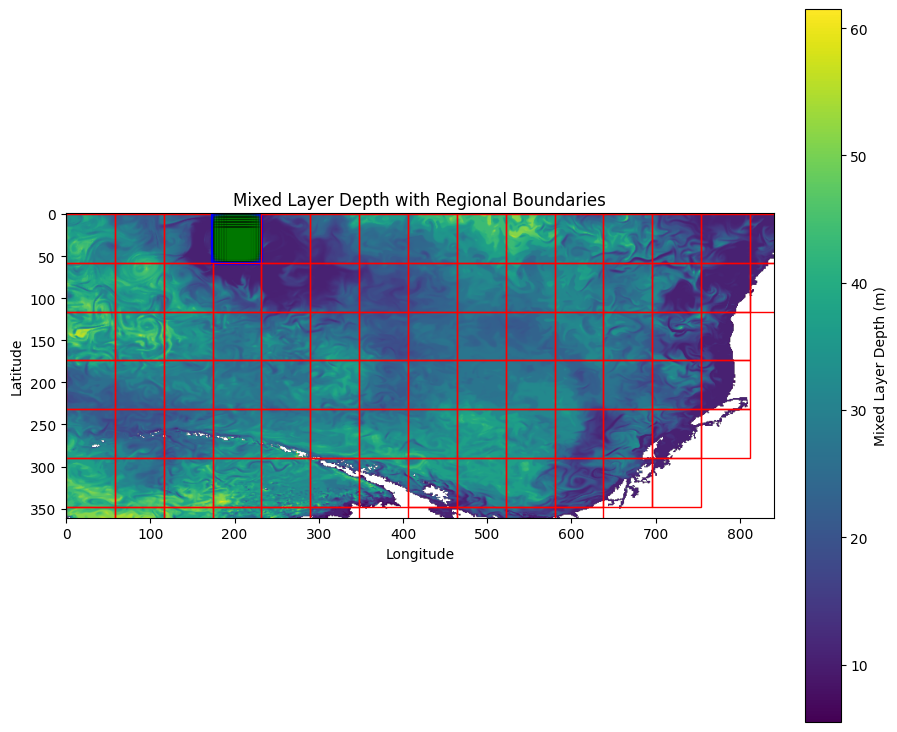

In [4]:
import numpy as np

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, max(len(regions)//5, 15)))
im = ax.imshow(retrieved_full_annot_oneday, cmap='viridis', )
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mixed Layer Depth (m)')

for (y, x) in regions:
    if (y, x) == list(ds.indices_regionified.keys())[3]:
        rect = plt.Rectangle((x, y), region_size, region_size, 
                         linewidth=3, edgecolor='blue', facecolor='none', alpha=1.0)
        ax.add_patch(rect)
        print(len(ds.indices_regionified[(y,x)]))
        for (_, grid_y, grid_x) in ds.indices_regionified[(y, x)]:
            rect = plt.Rectangle((grid_x, grid_y), grid_size, grid_size, 
                         linewidth=0.5, edgecolor='black', facecolor='green', alpha=0.1)
            ax.add_patch(rect)

    else:
        # rect = plt.Rectangle((x - 0.5, y - 0.5), region_size, region_size, 
        #                  linewidth=1, edgecolor='red', facecolor='none')
        rect = plt.Rectangle((x, y), region_size, region_size, 
                         linewidth=1, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

ax.set_title("Mixed Layer Depth with Regional Boundaries")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()